In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

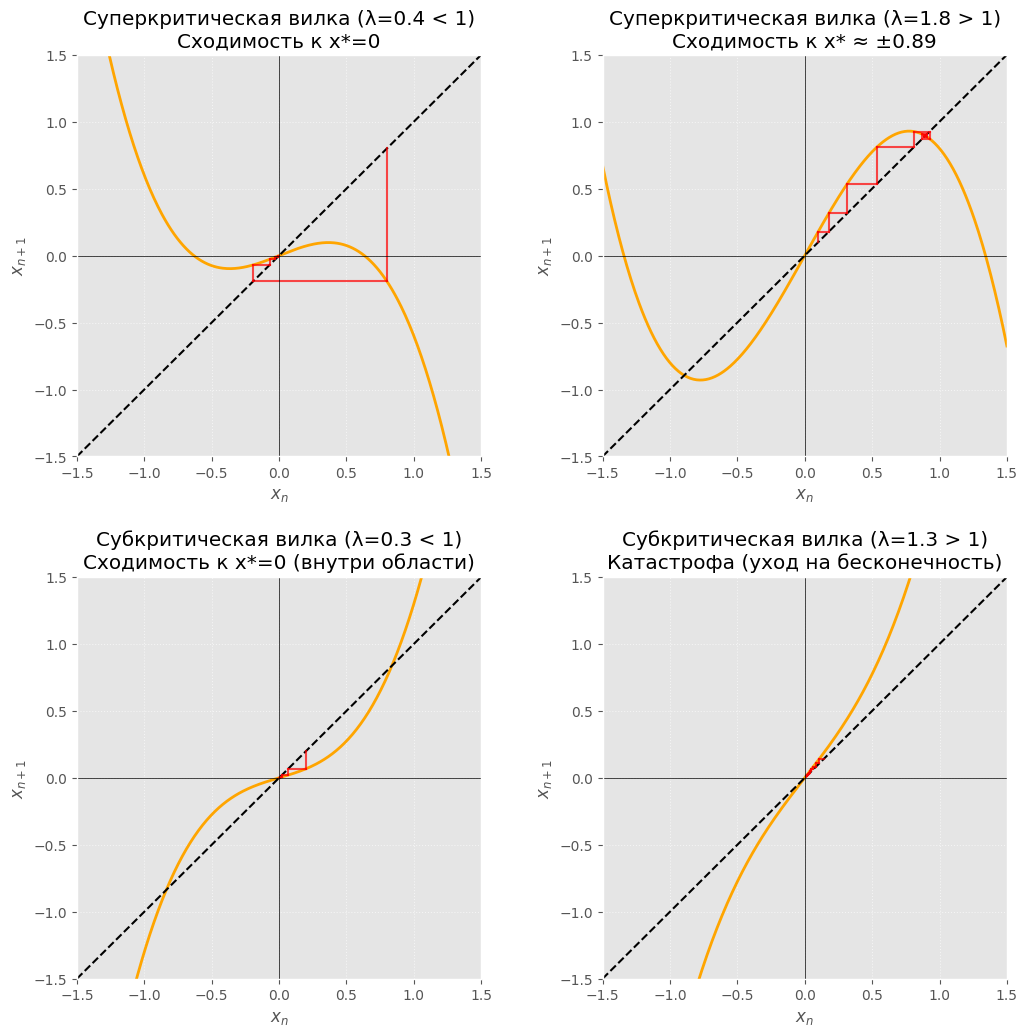

In [ ]:
def f_supercritical(x, lmbda):
    """Суперкритическая (прямая) вилка"""
    return lmbda * x - x ** 3


def f_subcritical(x, lmbda):
    """Субкритическая (обратная) вилка"""
    return lmbda * x + x ** 3


def plot_cobweb(ax, func, lmbda, x0, n_iter, x_range, title):
    # Создаем массив X для отрисовки графиков
    x = np.linspace(x_range[0], x_range[1], 400)
    y = func(x, lmbda)
    # Рисуем саму функцию f(x) и биссектрису y = x
    ax.plot(x, y, label=f'$f(x)$', color='orange', linewidth=2)
    ax.plot(x, x, label='$y = x$', color='black', linestyle='--')
    # Построение лестницы Ламерея
    x_n = x0
    for _ in range(n_iter):
        y_n = func(x_n, lmbda)
        ax.plot([x_n, x_n], [x_n, y_n], color='red', alpha=0.7, linewidth=1.5)
        ax.plot([x_n, y_n], [y_n, y_n], color='red', alpha=0.7, linewidth=1.5)
        x_n = y_n
        if abs(x_n) > max(abs(x_range[0]), abs(x_range[1])) * 2:
            break

    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel('$x_n$')
    ax.set_ylabel('$x_{n+1}$')
    ax.set_xlim(x_range)
    ax.set_ylim(x_range)
    ax.grid(True, linestyle=':', alpha=0.6)


fig, axes = plt.subplots(2, 2, figsize=(12, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# 1. Прямая вилка до порога (λ = 0.4)
plot_cobweb(axes[0, 0], f_supercritical, lmbda=0.4, x0=0.8, n_iter=20, x_range=(-1.5, 1.5),
            title="Суперкритическая вилка (λ=0.4 < 1)\nСходимость к x*=0")

# 2. Прямая вилка за порогом (λ = 1.8)
plot_cobweb(axes[0, 1], f_supercritical, lmbda=1.8, x0=0.1, n_iter=30, x_range=(-1.5, 1.5),
            title="Суперкритическая вилка (λ=1.8 > 1)\nСходимость к x* ≈ ±0.89")

# 3. Обратная вилка до порога (λ = 0.3)
plot_cobweb(axes[1, 0], f_subcritical, lmbda=0.3, x0=0.2, n_iter=20, x_range=(-1.5, 1.5),
            title="Субкритическая вилка (λ=0.3 < 1)\nСходимость к x*=0 (внутри области)")

# 4. Обратная вилка за порогом (λ = 1.3)
plot_cobweb(axes[1, 1], f_subcritical, lmbda=1.3, x0=0.01, n_iter=10, x_range=(-1.5, 1.5),
            title="Субкритическая вилка (λ=1.3 > 1)\nКатастрофа (уход на бесконечность)")

plt.show()